Fetching from Skinport API...
Total items from Skinport: 19562
Matched skins: 711
Knives found: 1152

Case                     Cost   Gross EV     Net EV   Return
------------------------------------------------------------
Kilowatt Case        $   5.94 $     0.94 $    -5.00   15.8%
Revolution Case      $   2.79 $     0.86 $    -1.93   30.8%
Fracture Case        $   3.07 $     8.85 $     5.78  288.4%
Glove Case           $  11.63 $    32.23 $    20.60  277.1%
Chroma 2 Case        $   9.07 $     7.06 $    -2.01   77.8%

Trade-Up (5x Covert) $ 313.46 $   194.68 $  -118.78   62.1%


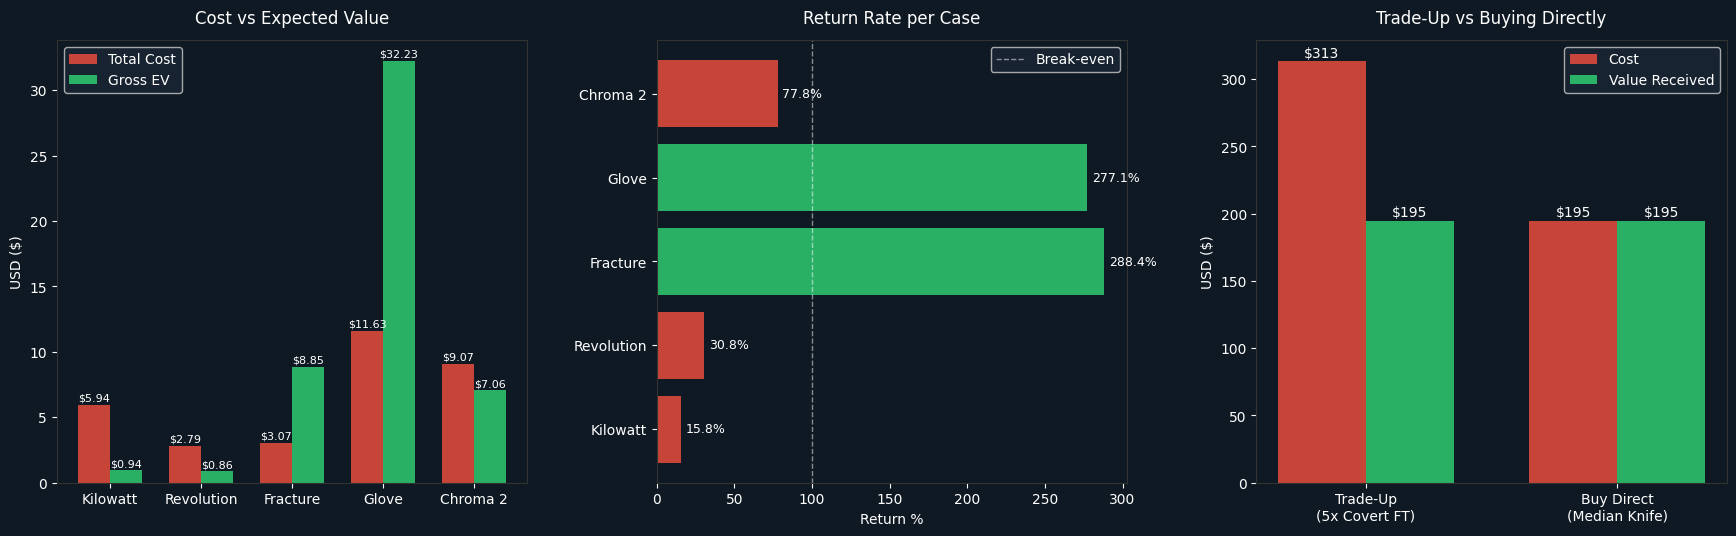

Done.


In [2]:
# ============================================================
# CS2 Case Opening EV Analysis
# Data: Skinport API (April 2026)
# Drop rates: Valve official disclosure (2017)
# ============================================================

import json
import brotli
import requests
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

# ── 1. Fetch all data from Skinport ─────────────────────────
SKINS = [
    "AWP | Chrome Cannon", "AK-47 | Inheritance", "USP-S | Jawbreaker",
    "Zeus x27 | Olympus", "M4A1-S | Black Lotus", "M4A4 | Etch Lord",
    "Five-SeveN | Hybrid", "MP7 | Just Smile", "Sawed-Off | Analog Input",
    "Glock-18 | Block-18", "Dual Berettas | Hideout", "Nova | Dark Sigil",
    "Tec-9 | Slag", "UMP-45 | Motorized", "MAC-10 | Light Box",
    "SSG 08 | Dezastre", "XM1014 | Irezumi",
    "AK-47 | Head Shot", "M4A4 | Temukau", "AWP | Duality",
    "P2000 | Wicked Sick", "UMP-45 | Wild Child", "Glock-18 | Umbral Rabbit",
    "M4A1-S | Emphorosaur-S", "MAC-10 | Sakkaku", "P90 | Neoqueen",
    "R8 Revolver | Banana Cannon", "MAG-7 | Foresight", "MP5-SD | Liquidation",
    "MP9 | Featherweight", "P250 | Verdigris", "SCAR-20 | Fragments",
    "SG 553 | Cyberforce", "Tec-9 | Rebel",
    "AK-47 | Legion of Anubis", "Desert Eagle | Printstream",
    "Glock-18 | Vogue", "M4A4 | Tooth Fairy", "XM1014 | Entombed",
    "C4 Bomb | Howitzer", "Galil AR | Connexion", "MAG-7 | Monster Call",
    "MP5-SD | Lab Rats", "Tec-9 | Brother", "AUG | Amber Slipstream",
    "CZ75-Auto | Distressed", "Five-SeveN | Angry Mob", "P90 | Freight",
    "SG 553 | Ol' Rusty", "SSG 08 | Mainframe 001", "UMP-45 | Scaffold",
    "AK-47 | Bloodsport", "AWP | Hyper Beast", "M4A4 | Buzz Kill",
    "MP7 | Fade", "P250 | See Ya Later", "AUG | Aristocrat",
    "CZ75-Auto | Emerald Quartz", "Glock-18 | Wasteland Rebel",
    "MAC-10 | Rangeen", "Tec-9 | Avalanche", "Dual Berettas | Dualing Dragons",
    "FAMAS | Spitfire", "MAG-7 | Praetorian", "MP9 | Bioleak",
    "Nova | Antique", "P90 | Shallow Grave", "Sawed-Off | Wasteland Princess",
    "M4A1-S | Hyper Beast", "MAC-10 | Neon Rider", "FAMAS | Djinn",
    "Five-SeveN | Monkey Business", "Galil AR | Eco", "AWP | Worm God",
    "CZ75-Auto | Pole Position", "MAG-7 | Heat", "UMP-45 | Grand Prix",
    "Dual Berettas | Capper", "MP7 | Impire", "Nova | Ranger",
    "P250 | Muertos", "Tec-9 | Isaac",
    "MP9 | Starlight Protector", "AK-47 | Nightwish", "FAMAS | Bad Trip",
]

WEARS = ["Factory New", "Minimal Wear", "Field-Tested", "Well-Worn", "Battle-Scarred"]

KNIFE_TYPES = [
    "Karambit", "Butterfly Knife", "M9 Bayonet", "Bayonet",
    "Flip Knife", "Gut Knife", "Falchion Knife", "Shadow Daggers",
    "Bowie Knife", "Huntsman Knife", "Navaja Knife", "Stiletto Knife",
    "Talon Knife", "Ursus Knife", "Skeleton Knife", "Nomad Knife",
    "Paracord Knife", "Survival Knife", "Classic Knife", "Kukri Knife",
]

print("Fetching from Skinport API...")
r = requests.get(
    "https://api.skinport.com/v1/items",
    params={"app_id": 730, "currency": "USD", "tradable": 0},
    headers={"Accept-Encoding": "br"},
    timeout=60,
)
try:
    raw = brotli.decompress(r.content)
    all_data = json.loads(raw)
except Exception:
    all_data = r.json()

print(f"Total items from Skinport: {len(all_data)}")

# Build price lookup dict
all_data_dict = {item["market_hash_name"]: item for item in all_data}

# Filter skins we need
all_names = set()
for skin in SKINS:
    for wear in WEARS:
        all_names.add(f"{skin} ({wear})")
        all_names.add(f"StatTrak\u2122 {skin} ({wear})")

prices = {k: all_data_dict[k] for k in all_names if k in all_data_dict}
print(f"Matched skins: {len(prices)}")

# Filter knives
knives_data = [
    item for item in all_data
    if not any(x in item["market_hash_name"] for x in ["StatTrak", "Souvenir"])
    and any(k in item["market_hash_name"] for k in KNIFE_TYPES)
    and item["median_price"] is not None
]
print(f"Knives found: {len(knives_data)}")

# ── 2. EV Calculation ─────────────────────────────────────────

RARITY_PROBS = {
    "Mil-Spec":     0.7992,
    "Restricted":   0.1598,
    "Classified":   0.0320,
    "Covert":       0.0064,
    "Knife/Gloves": 0.0026,
}

WEAR_WEIGHTS = {
    "Factory New":    0.03,
    "Minimal Wear":   0.24,
    "Field-Tested":   0.33,
    "Well-Worn":      0.24,
    "Battle-Scarred": 0.16,
}

KEY_PRICE = 2.49

def get_price(skin_name, wear, stattrak=False):
    prefix = "StatTrak\u2122 " if stattrak else ""
    entry = prices.get(f"{prefix}{skin_name} ({wear})")
    if entry is None:
        return None
    return entry["median_price"]

def weighted_avg_price(skin_name, stattrak=False):
    total_w, total_p = 0.0, 0.0
    for wear, w in WEAR_WEIGHTS.items():
        p = get_price(skin_name, wear, stattrak)
        if p is None:
            continue
        total_p += p * w
        total_w += w
    return (total_p / total_w) if total_w > 0 else None

def skin_ev_with_stattrak(skin_name):
    ev_normal = weighted_avg_price(skin_name, stattrak=False)
    ev_st     = weighted_avg_price(skin_name, stattrak=True)
    ev = 0
    if ev_normal: ev += 0.9 * ev_normal
    if ev_st:     ev += 0.1 * ev_st
    return ev if ev > 0 else None

def case_gross_ev(skin_list):
    rarity_counts = Counter(r for _, r in skin_list)
    gross_ev = 0.0
    for skin, rarity in skin_list:
        prob = RARITY_PROBS[rarity] / rarity_counts[rarity]
        avg  = skin_ev_with_stattrak(skin)
        if avg:
            gross_ev += prob * avg
    return gross_ev

ALL_CASES = {
    "Kilowatt Case": {
        "price": 3.45,
        "skins": [
            ("AWP | Chrome Cannon",     "Covert"),
            ("AK-47 | Inheritance",     "Covert"),
            ("USP-S | Jawbreaker",      "Classified"),
            ("Zeus x27 | Olympus",      "Classified"),
            ("M4A1-S | Black Lotus",    "Classified"),
            ("M4A4 | Etch Lord",        "Restricted"),
            ("Five-SeveN | Hybrid",     "Restricted"),
            ("MP7 | Just Smile",        "Restricted"),
            ("Sawed-Off | Analog Input","Restricted"),
            ("Glock-18 | Block-18",     "Restricted"),
            ("Dual Berettas | Hideout", "Mil-Spec"),
            ("Nova | Dark Sigil",       "Mil-Spec"),
            ("Tec-9 | Slag",            "Mil-Spec"),
            ("UMP-45 | Motorized",      "Mil-Spec"),
            ("MAC-10 | Light Box",      "Mil-Spec"),
            ("SSG 08 | Dezastre",       "Mil-Spec"),
            ("XM1014 | Irezumi",        "Mil-Spec"),
        ]
    },
    "Revolution Case": {
        "price": 0.30,
        "skins": [
            ("AK-47 | Head Shot",           "Covert"),
            ("M4A4 | Temukau",              "Covert"),
            ("AWP | Duality",               "Classified"),
            ("P2000 | Wicked Sick",         "Classified"),
            ("UMP-45 | Wild Child",         "Classified"),
            ("Glock-18 | Umbral Rabbit",    "Restricted"),
            ("M4A1-S | Emphorosaur-S",      "Restricted"),
            ("MAC-10 | Sakkaku",            "Restricted"),
            ("P90 | Neoqueen",              "Restricted"),
            ("R8 Revolver | Banana Cannon", "Restricted"),
            ("MAG-7 | Foresight",           "Mil-Spec"),
            ("MP5-SD | Liquidation",        "Mil-Spec"),
            ("MP9 | Featherweight",         "Mil-Spec"),
            ("P250 | Verdigris",            "Mil-Spec"),
            ("SCAR-20 | Fragments",         "Mil-Spec"),
            ("SG 553 | Cyberforce",         "Mil-Spec"),
            ("Tec-9 | Rebel",               "Mil-Spec"),
        ]
    },
    "Fracture Case": {
        "price": 0.58,
        "skins": [
            ("AK-47 | Legion of Anubis",    "Covert"),
            ("Desert Eagle | Printstream",  "Covert"),
            ("Glock-18 | Vogue",            "Classified"),
            ("M4A4 | Tooth Fairy",          "Classified"),
            ("XM1014 | Entombed",           "Classified"),
            ("C4 Bomb | Howitzer",          "Restricted"),
            ("Galil AR | Connexion",        "Restricted"),
            ("MAG-7 | Monster Call",        "Restricted"),
            ("MP5-SD | Lab Rats",           "Restricted"),
            ("Tec-9 | Brother",             "Restricted"),
            ("AUG | Amber Slipstream",      "Mil-Spec"),
            ("CZ75-Auto | Distressed",      "Mil-Spec"),
            ("Five-SeveN | Angry Mob",      "Mil-Spec"),
            ("P90 | Freight",               "Mil-Spec"),
            ("SG 553 | Ol' Rusty",          "Mil-Spec"),
            ("SSG 08 | Mainframe 001",      "Mil-Spec"),
            ("UMP-45 | Scaffold",           "Mil-Spec"),
        ]
    },
    "Glove Case": {
        "price": 9.14,
        "skins": [
            ("AK-47 | Bloodsport",              "Covert"),
            ("AWP | Hyper Beast",               "Covert"),
            ("M4A4 | Buzz Kill",                "Classified"),
            ("MP7 | Fade",                      "Classified"),
            ("P250 | See Ya Later",             "Classified"),
            ("AUG | Aristocrat",                "Restricted"),
            ("CZ75-Auto | Emerald Quartz",      "Restricted"),
            ("Glock-18 | Wasteland Rebel",      "Restricted"),
            ("MAC-10 | Rangeen",                "Restricted"),
            ("Tec-9 | Avalanche",               "Restricted"),
            ("Dual Berettas | Dualing Dragons", "Mil-Spec"),
            ("FAMAS | Spitfire",                "Mil-Spec"),
            ("MAG-7 | Praetorian",              "Mil-Spec"),
            ("MP9 | Bioleak",                   "Mil-Spec"),
            ("Nova | Antique",                  "Mil-Spec"),
            ("P90 | Shallow Grave",             "Mil-Spec"),
            ("Sawed-Off | Wasteland Princess",  "Mil-Spec"),
        ]
    },
    "Chroma 2 Case": {
        "price": 6.58,
        "skins": [
            ("M4A1-S | Hyper Beast",            "Covert"),
            ("MAC-10 | Neon Rider",             "Covert"),
            ("FAMAS | Djinn",                   "Classified"),
            ("Five-SeveN | Monkey Business",    "Classified"),
            ("Galil AR | Eco",                  "Classified"),
            ("AWP | Worm God",                  "Restricted"),
            ("CZ75-Auto | Pole Position",       "Restricted"),
            ("MAG-7 | Heat",                    "Restricted"),
            ("UMP-45 | Grand Prix",             "Restricted"),
            ("Dual Berettas | Capper",          "Mil-Spec"),
            ("MP7 | Impire",                    "Mil-Spec"),
            ("Nova | Ranger",                   "Mil-Spec"),
            ("P250 | Muertos",                  "Mil-Spec"),
            ("Tec-9 | Isaac",                   "Mil-Spec"),
        ]
    },
}

# ── 3. Results ────────────────────────────────────────────────
print(f"\n{'Case':<20} {'Cost':>8} {'Gross EV':>10} {'Net EV':>10} {'Return':>8}")
print("-" * 60)

results_summary = []
for case_name, info in ALL_CASES.items():
    gross      = case_gross_ev(info["skins"])
    total_cost = info["price"] + KEY_PRICE
    net        = gross - total_cost
    ret        = gross / total_cost
    results_summary.append((case_name, total_cost, gross, net, ret))
    print(f"{case_name:<20} ${total_cost:>7.2f} ${gross:>9.2f} ${net:>9.2f} {ret:>7.1%}")

# Trade-Up
tradeup_inputs = [
    ("AK-47 | Legion of Anubis",   "Field-Tested"),
    ("Desert Eagle | Printstream", "Field-Tested"),
    ("MP9 | Starlight Protector",  "Field-Tested"),
    ("AK-47 | Nightwish",          "Field-Tested"),
    ("FAMAS | Bad Trip",           "Field-Tested"),
]
tradeup_cost = sum(
    prices[f"{s} ({w})"]["median_price"]
    for s, w in tradeup_inputs
    if f"{s} ({w})" in prices
)
knife_prices = [item["median_price"] for item in knives_data]
median_knife = sorted(knife_prices)[len(knife_prices) // 2]
tradeup_net  = median_knife - tradeup_cost
tradeup_roi  = median_knife / tradeup_cost

print(f"\n{'Trade-Up (5x Covert)':<20} ${tradeup_cost:>7.2f} ${median_knife:>9.2f} ${tradeup_net:>9.2f} {tradeup_roi:>7.1%}")

# ── 4. Visualization ──────────────────────────────────────────
cases_labels = [r[0].replace(" Case", "") for r in results_summary]
costs_v      = [r[1] for r in results_summary]
gross_evs_v  = [r[2] for r in results_summary]
returns_v    = [r[4] * 100 for r in results_summary]
width        = 0.35

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.patch.set_facecolor("#0f1923")

# Chart 1: Cost vs EV
ax1 = axes[0]
ax1.set_facecolor("#0f1923")
x = np.arange(len(cases_labels))
ax1.bar(x - width/2, costs_v,     width, label="Total Cost", color="#e74c3c", alpha=0.85)
ax1.bar(x + width/2, gross_evs_v, width, label="Gross EV",   color="#2ecc71", alpha=0.85)
ax1.set_xticks(x)
ax1.set_xticklabels(cases_labels, color="white", fontsize=10)
ax1.set_ylabel("USD ($)", color="white")
ax1.set_title("Cost vs Expected Value", color="white", fontsize=12, pad=12)
ax1.tick_params(colors="white")
ax1.spines[:].set_color("#333")
ax1.legend(facecolor="#1a2634", labelcolor="white")
for i, (c, e) in enumerate(zip(costs_v, gross_evs_v)):
    ax1.text(i - width/2, c + 0.3, f"${c:.2f}", ha="center", color="white", fontsize=8)
    ax1.text(i + width/2, e + 0.3, f"${e:.2f}", ha="center", color="white", fontsize=8)

# Chart 2: Return Rate
ax2 = axes[1]
ax2.set_facecolor("#0f1923")
bar_colors = ["#e74c3c" if r < 100 else "#2ecc71" for r in returns_v]
bars = ax2.barh(cases_labels, returns_v, color=bar_colors, alpha=0.85)
ax2.axvline(x=100, color="white", linestyle="--", linewidth=1, alpha=0.5, label="Break-even")
ax2.set_xlabel("Return %", color="white")
ax2.set_title("Return Rate per Case", color="white", fontsize=12, pad=12)
ax2.tick_params(colors="white")
ax2.spines[:].set_color("#333")
ax2.legend(facecolor="#1a2634", labelcolor="white")
for bar, r in zip(bars, returns_v):
    ax2.text(bar.get_width() + 3, bar.get_y() + bar.get_height() / 2,
             f"{r:.1f}%", va="center", color="white", fontsize=9)

# Chart 3: Trade-Up vs Buy Direct
ax3 = axes[2]
ax3.set_facecolor("#0f1923")
m2 = ["Trade-Up\n(5x Covert FT)", "Buy Direct\n(Median Knife)"]
c2 = [tradeup_cost, median_knife]
v2 = [median_knife, median_knife]
x3 = np.arange(2)
ax3.bar(x3 - width/2, c2, width, label="Cost",           color="#e74c3c", alpha=0.85)
ax3.bar(x3 + width/2, v2, width, label="Value Received", color="#2ecc71", alpha=0.85)
ax3.set_xticks(x3)
ax3.set_xticklabels(m2, color="white", fontsize=10)
ax3.set_ylabel("USD ($)", color="white")
ax3.set_title("Trade-Up vs Buying Directly", color="white", fontsize=12, pad=12)
ax3.tick_params(colors="white")
ax3.spines[:].set_color("#333")
ax3.legend(facecolor="#1a2634", labelcolor="white")
for i, (c, v) in enumerate(zip(c2, v2)):
    ax3.text(i - width/2, c + 3, f"${c:.0f}", ha="center", color="white", fontsize=10)
    ax3.text(i + width/2, v + 3, f"${v:.0f}", ha="center", color="white", fontsize=10)

plt.tight_layout(pad=3)
plt.savefig("cs2_ev_charts.png", dpi=150, bbox_inches="tight", facecolor="#0f1923")
plt.show()
print("Done.")